# Five-player Cournot game with MMNN: evolving parameters and particle values

This deterministic example advances the NN parameters and the particle map values at every step. The evolving NN supplies the tangent Jacobian; the particle values are stored and advanced separately. There are no resets or NN refits.

With $b=2$, $\mu=7/4$, and $s_i=\sum_{j\ne i}x_j$, the game velocity is

$$F_i(x)=2b\left(\max\{\mu s_i(1-s_i),0\}-x_i\right).$$

Initial particles are uniform on $[0,1]^5$. Run all cells for the point clouds in $(x_1,x_2)$, $(x_2,x_3)$, $(x_3,x_4)$, and $(x_4,x_5)$, followed by the projection-error trajectory.

MMNN duplicate of the [original notebook](https://github.com/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/DTB_Game_Ver2/cournot_5d_b2_mu7_4_dtb.ipynb). Upload this `.ipynb` to Colab and run all cells.

In [2]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

# Use the existing helpers locally, or obtain them when running in Colab.
module_files = ('dtb.py', 'run_game_dtb.py', 'network.py')
module_dir = next((p for p in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
                   if all((p / name).is_file() for name in module_files)), None)
if module_dir is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2.')
    repo = Path('/content/dtb-colab-experiments')
    if not repo.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    module_dir = repo / 'DTB_Game_Ver2'
sys.path.insert(0, str(module_dir.resolve()))

from dtb import flat_params
from run_game_dtb import game_dtb_basis_matrices
from network import MMNN

output_dir = Path("/content/cournot_5d_mmnn_results")
output_dir.mkdir(parents=True, exist_ok=True)

## Parameters

The residual tanh MMNN and particle map both start at the identity. The MMNN has five inputs and five outputs, with shape `(WIDTH, RANK, DEPTH) = (16, 16, 2)`. Each layer uses frozen `W,b` and trainable `A,c`. The final `A,c` start at zero, so `T_theta(z) = z + MMNN_theta(z)` initially equals `z`. As with the original zero-output MLP, earlier-layer parameter derivatives initially vanish; they become active as the output weights evolve. Select 128 parameter coordinates at each step, compute the tangent projection, and use the same coefficients to update those parameters and the particle values.

In [3]:
SEED = 0
DIM = 5
COURNOT_B = 2.0
COURNOT_MU = 7 / 4
N_PARTICLES = 3000

H = 0.005
T_FINAL = 2
SNAPSHOT_TIMES = (0.0, 0.5, 1.0, T_FINAL)
WIDTH, RANK, DEPTH = 16, 16, 2
BASIS_SIZE = 64
SVD_RTOL = 1e-6  # Retain singular values above SVD_RTOL * s_max.
JACOBIAN_CHUNK = 256

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))


def game_velocity(x):
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1 - rivals)).clamp_min(0.0)
    return 2 * COURNOT_B * (best_response - x)

## Evolve parameters and particles separately

Keep the reference labels $z_i$ fixed and initialize $x_i^0=z_i$. At step $k$, select parameter coordinates $S_k$ and evaluate

$$J_i^k=\partial_{\theta_{S_k}}T_{\theta_k}(z_i),\qquad g_i^k=F(x_i^k).$$

For $A=J^k/\sqrt N=U\Sigma V^\top$ and $y=\operatorname{vec}(g^k)/\sqrt N$, retain $s_\ell>\texttt{SVD\_RTOL}\,s_{\max}$ and solve

$$\alpha^k=V_{\rm keep}\Sigma_{\rm keep}^{-1}U_{\rm keep}^\top y.$$

Update both states using this same old-step Jacobian and coefficient vector:

$$\theta_{k+1}=\theta_k+h_k E_{S_k}\alpha^k,
\qquad x_i^{k+1}=x_i^k+h_kJ_i^k\alpha^k.$$

Here $E_{S_k}$ inserts the $m$ coefficients into the selected entries of the full parameter vector; other entries are unchanged at that step. The parameter increment is $h_k\alpha^k$ on $S_k$: $J^k\alpha^k$ has particle-space dimensions and is the increment direction for $X$.

**The new particle values are never replaced by $T_{\theta_{k+1}}(z_i)$.** The next Jacobian uses $\theta_{k+1}$ at the fixed labels, while the next game velocity uses the independently accumulated $x_i^{k+1}$. No reset or refit is performed.

The error curve records $\|J^k\alpha^k-g^k\|/\sqrt N$ at the start of each step. Every snapshot comes from the accumulated particle values.

The result is the accumulated map evaluated at the reference samples:

$$X_K(z_i)=z_i+\sum_{k=0}^{K-1}h_kJ_i^k\alpha^k.$$

`X_final` stores these final values with shape `(N_PARTICLES, DIM)`. `clouds[t]` stores the accumulated map values at each requested snapshot time. The NN parameters are used only to construct the successive Jacobians; no final NN is written back or returned as the result.


In [4]:
class ResidualMMNNMap(torch.nn.Module):
    """T_theta(z) = z + MMNN_theta(z), initialized to the identity."""

    def __init__(self, dim, width, rank, depth, activation='tanh',
                 dtype=torch.float64):
        super().__init__()
        self.net = MMNN(d_in=dim, width=width, rank=rank, depth=depth,
                        d_out=dim, activation=activation, dtype=dtype)
        # Match the original residual MLP's exact identity initialization.
        # W,b remain frozen; only A,c participate in the DTB parameter vector.
        with torch.no_grad():
            self.net.layers[-1].A.zero_()
            self.net.layers[-1].c.zero_()

    def forward(self, z):
        return z + self.net(z)


# Rerunning this cell restarts both states from the identity map.
torch.manual_seed(SEED)
basis_generator = torch.Generator().manual_seed(SEED + 1)
z = torch.rand(N_PARTICLES, DIM, generator=torch.Generator().manual_seed(SEED),
               dtype=DTYPE).to(DEVICE)
x = z.clone()  # Independently accumulated particle map X^k(z_i).
model = ResidualMMNNMap(dim=DIM, width=WIDTH, rank=RANK, depth=DEPTH,
                        activation='tanh', dtype=DTYPE).to(DEVICE)
theta, structure, _ = flat_params(model)

snapshot_times = np.unique(np.round(SNAPSHOT_TIMES, 12))
times = np.unique(np.round(np.r_[np.arange(0, T_FINAL, H), snapshot_times, T_FINAL], 12))
projection_times = times[:-1]
projection_error = []
clouds = {0.0: x.cpu().numpy().copy()}

for k, t in enumerate(projection_times):
    indices = torch.randperm(theta.numel(), generator=basis_generator)
    selected = indices[:BASIS_SIZE].sort().values.to(DEVICE)
    _, _, J_flat = game_dtb_basis_matrices(
        theta, selected, z, model, structure, chunk=JACOBIAN_CHUNK)
    J_flat = J_flat.detach()

    velocity = game_velocity(x)
    A = J_flat / np.sqrt(N_PARTICLES)
    target = velocity.reshape(-1) / np.sqrt(N_PARTICLES)
    U, s, Vh = torch.linalg.svd(A, full_matrices=False)
    keep = s > SVD_RTOL * s[0]
    alpha = Vh[keep].T @ ((U[:, keep].T @ target) / s[keep])
    tangent_velocity = (J_flat @ alpha).reshape_as(x)
    error = (tangent_velocity - velocity).square().sum(dim=1).mean().sqrt()
    if not torch.isfinite(error):
        raise FloatingPointError(f'Nonfinite tangent projection at t={t:g}.')
    projection_error.append(error.item())

    next_time = float(times[k + 1])
    h = next_time - float(t)
    # Both increments use J(theta_k, z) and alpha_k computed above.
    theta[selected] += h * alpha
    x = (x + h * tangent_velocity).detach()
    if not torch.isfinite(theta).all() or not torch.isfinite(x).all():
        raise FloatingPointError(f'Nonfinite state at t={next_time:g}.')

    if next_time in snapshot_times:
        clouds[next_time] = x.cpu().numpy().copy()

# Final accumulated map values on the fixed labels z.
X_final = x.detach().clone()
projection_error = np.asarray(projection_error)

## Point-cloud projections

Rows show the four adjacent coordinate pairs; columns show physical time. All particles are displayed, with common axis limits across the figure.

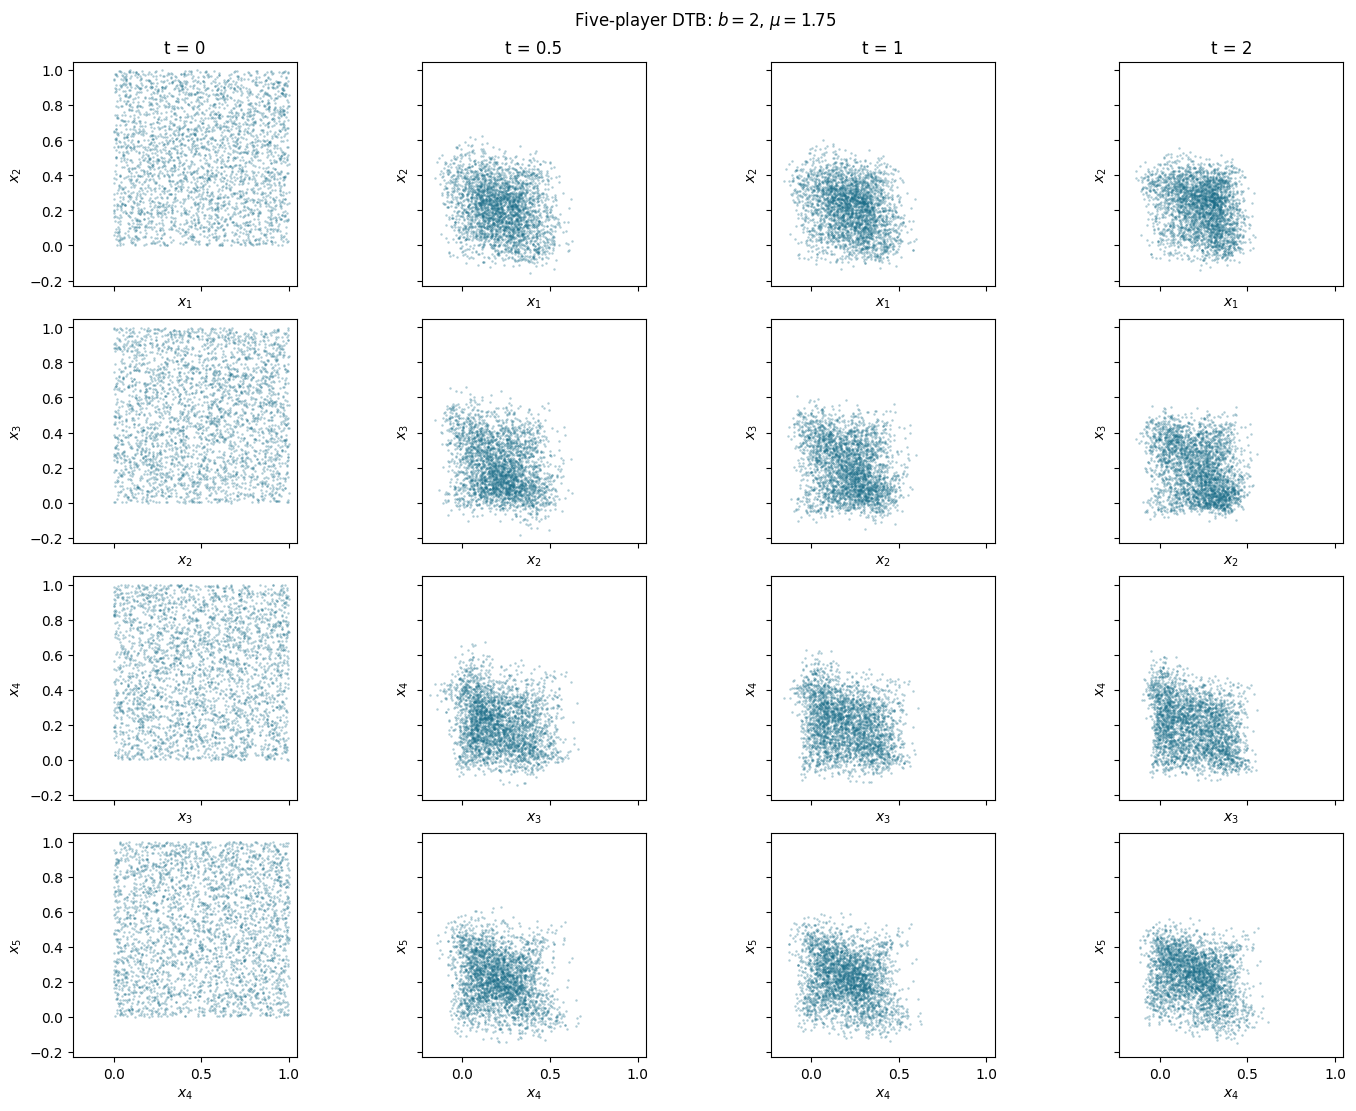

In [5]:
pairs = ((0, 1), (1, 2), (2, 3), (3, 4))
fig, axes = plt.subplots(4, len(clouds), figsize=(3.5 * len(clouds), 11),
                         sharex=True, sharey=True, squeeze=False, layout='constrained')
lo = min(points.min() for points in clouds.values())
hi = max(points.max() for points in clouds.values())
padding = 0.04 * max(hi - lo, 1e-6)

for row, (i, j) in enumerate(pairs):
    for col, (t, points) in enumerate(clouds.items()):
        ax = axes[row, col]
        ax.scatter(points[:, i], points[:, j], s=3, alpha=0.35,
                   color='#176b87', linewidths=0, rasterized=True)
        ax.set(xlabel=fr'$x_{i + 1}$', ylabel=fr'$x_{j + 1}$',
               xlim=(lo - padding, hi + padding), ylim=(lo - padding, hi + padding))
        ax.set_aspect('equal', adjustable='box')
        if row == 0:
            ax.set_title(f't = {t:g}')
fig.suptitle(fr'Five-player DTB: $b={COURNOT_B:g}$, $\mu={COURNOT_MU:g}$')
fig.savefig(output_dir / "point_clouds.png",
            dpi=300, bbox_inches="tight")
plt.show()

## Projection-error trajectory

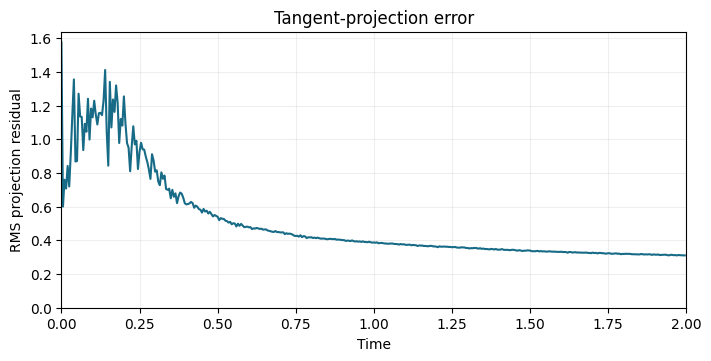

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
ax.plot(projection_times, projection_error, color='#176b87', linewidth=1.5)
ax.set(xlabel='Time', ylabel='RMS projection residual',
       title='Tangent-projection error', xlim=(0, T_FINAL), ylim=(0, None))
ax.grid(alpha=0.2)
fig.savefig(output_dir / "projection_error.png",
            dpi=300, bbox_inches="tight")
plt.show()

## Euler–Maruyama reference on the same samples and time grid

This reference advances the game velocity directly, without a neural tangent projection. It starts from a copy of the same initial particles `z` and uses the exact DTB `times` array, so the sample count, every step size, and snapshot times match.

For an SDE, Euler–Maruyama has the form

$$X_{k+1}^{\mathrm{EM}}=X_k^{\mathrm{EM}}+h_k F(X_k^{\mathrm{EM}})+\sigma\sqrt{h_k}\,\xi_k.$$

The game in this notebook is deterministic: **$\sigma=0$**, so EM reduces to explicit Euler and no random noise is added. This is a numerical reference at the same step size, not an exact solution. The MMNN parameters and DTB particle state are not changed.

`X_em_final` stores the final reference particles; `clouds_em` stores snapshots. The printed RMS distance compares matched DTB and EM particles at the final time.


In [7]:
# Run after the DTB evolution cell; rerunning starts from the same z.
x_em = z.detach().clone()
clouds_em = {float(times[0]): x_em.cpu().numpy().copy()}
em_snapshot_times = set(clouds)

with torch.no_grad():
    for em_t, em_next_time in zip(times[:-1], times[1:]):
        em_h = float(em_next_time - em_t)
        # Euler–Maruyama with zero diffusion for this deterministic game.
        x_em = x_em + em_h * game_velocity(x_em)
        if not torch.isfinite(x_em).all():
            raise FloatingPointError(f'Nonfinite EM state at t={em_next_time:g}.')
        if float(em_next_time) in em_snapshot_times:
            clouds_em[float(em_next_time)] = x_em.cpu().numpy().copy()

X_em_final = x_em.detach().clone()
em_final_rms_distance = (
    (X_final - X_em_final).square().sum(dim=1).mean().sqrt().item()
)
print(f'EM reference: {z.shape[0]} particles, {len(times) - 1} steps, '
      f'nominal H={H:g}, final time={times[-1]:g}.')
print(f'Final RMS particle distance (DTB vs EM): {em_final_rms_distance:.6g}')


EM reference: 3000 particles, 400 steps, nominal H=0.005, final time=2.
Final RMS particle distance (DTB vs EM): 0.197672


## EM reference: four projection planes

Rows show $(x_1,x_2)$, $(x_2,x_3)$, $(x_3,x_4)$, and $(x_4,x_5)$; columns show the same snapshot times as the DTB figure. Every initial sample is retained. Common axis limits cover both the DTB and EM snapshots. The figure is saved as `em_point_clouds.png` and included by the download block below.


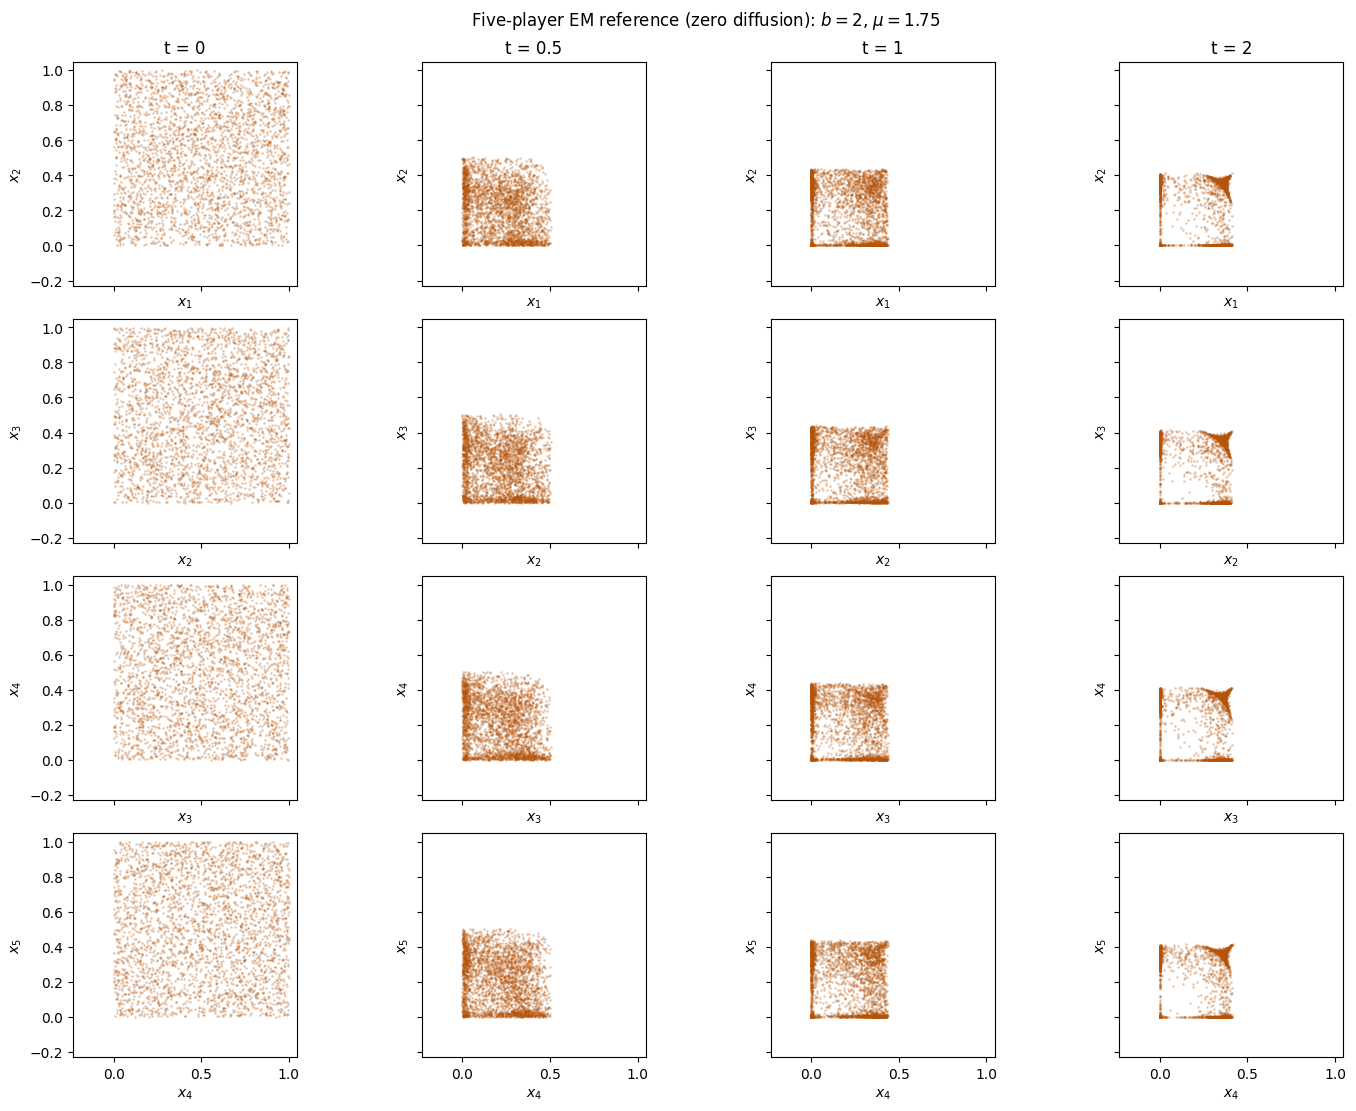

In [8]:
em_pairs = ((0, 1), (1, 2), (2, 3), (3, 4))
em_fig, em_axes = plt.subplots(
    4, len(clouds_em), figsize=(3.5 * len(clouds_em), 11),
    sharex=True, sharey=True, squeeze=False, layout='constrained',
)
em_all_clouds = list(clouds.values()) + list(clouds_em.values())
em_lo = min(points.min() for points in em_all_clouds)
em_hi = max(points.max() for points in em_all_clouds)
em_padding = 0.04 * max(em_hi - em_lo, 1e-6)

for em_row, (em_i, em_j) in enumerate(em_pairs):
    for em_col, (em_time, em_points) in enumerate(clouds_em.items()):
        em_ax = em_axes[em_row, em_col]
        em_ax.scatter(em_points[:, em_i], em_points[:, em_j], s=3, alpha=0.35,
                      color='#b45309', linewidths=0, rasterized=True)
        em_ax.set(xlabel=fr'$x_{em_i + 1}$', ylabel=fr'$x_{em_j + 1}$',
                  xlim=(em_lo - em_padding, em_hi + em_padding),
                  ylim=(em_lo - em_padding, em_hi + em_padding))
        em_ax.set_aspect('equal', adjustable='box')
        if em_row == 0:
            em_ax.set_title(f't = {em_time:g}')
em_fig.suptitle(
    fr'Five-player EM reference (zero diffusion): $b={COURNOT_B:g}$, '
    fr'$\mu={COURNOT_MU:g}$'
)
em_fig.savefig(output_dir / 'em_point_clouds.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
from pathlib import Path
import shutil
from google.colab import files

run_folder = Path(output_dir)

zip_path = shutil.make_archive(
    f"/content/{run_folder.name}",
    "zip",
    root_dir=str(run_folder.parent),
    base_dir=run_folder.name,
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>